<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [4]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')

In [5]:
print(housing.shape)
housing.head()

(985, 12)


,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [6]:
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [7]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [8]:
housing['zip']=housing['zip'].astype(str)

In [9]:
housing['sale_date'] = housing['sale_date'].str.replace(' EDT ', ' ', regex=False)
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format='%a %b %d %H:%M:%S %Y')

In [10]:
housing['state'].value_counts()

state
CA    984
AC      1
Name: count, dtype: int64

In [11]:
housing['state'] = housing['state'].replace('AC','CA')

In [12]:
housing['state'].value_counts()

state
CA    985
Name: count, dtype: int64

In [13]:
housing.dtypes

street                  str
city                    str
zip                     str
state                   str
beds                  int64
baths                 int64
sq__ft                int64
type                    str
sale_date    datetime64[us]
price                 int64
latitude            float64
longitude           float64
dtype: object

In [14]:
housing['city'].value_counts()

city
SACRAMENTO         439
ELK GROVE          114
LINCOLN             72
ROSEVILLE           48
CITRUS HEIGHTS      35
ANTELOPE            33
RANCHO CORDOVA      28
EL DORADO HILLS     23
NORTH HIGHLANDS     21
GALT                21
CARMICHAEL          20
FOLSOM              17
ROCKLIN             17
RIO LINDA           13
ORANGEVALE          11
PLACERVILLE         10
FAIR OAKS            9
CAMERON PARK         9
WILTON               5
AUBURN               5
ELVERTA              4
GOLD RIVER           4
POLLOCK PINES        3
RANCHO MURIETA       3
GRANITE BAY          3
WEST SACRAMENTO      3
LOOMIS               2
EL DORADO            2
MATHER               1
GREENWOOD            1
MEADOW VISTA         1
PENRYN               1
FORESTHILL           1
DIAMOND SPRINGS      1
SHINGLE SPRINGS      1
COOL                 1
WALNUT GROVE         1
GARDEN VALLEY        1
SLOUGHHOUSE          1
Name: count, dtype: int64

In [15]:
housing['type'].value_counts()

type
Residential     917
Condo            54
Multi-Family     13
Unkown            1
Name: count, dtype: int64

In [16]:
housing = housing[housing['type'] != 'Unkown']
housing['type'].value_counts()

type
Residential     917
Condo            54
Multi-Family     13
Name: count, dtype: int64

In [17]:
housing= housing[housing['price'] >0]


In [18]:
housing =housing[(housing['beds'] > 0) | (housing['baths'] > 0)]
housing =housing[ (housing['baths'] > 0)]
((housing['beds'] <= 0) | (housing['baths'] <= 0)).sum()

np.int64(0)

In [19]:
housing = housing[housing['sq__ft']>0]

In [20]:
housing['state'].value_counts()

state
CA    813
Name: count, dtype: int64

In [21]:
housing.shape

(813, 12)

In [22]:
housing.head(1)

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879


When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [23]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv', index=False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

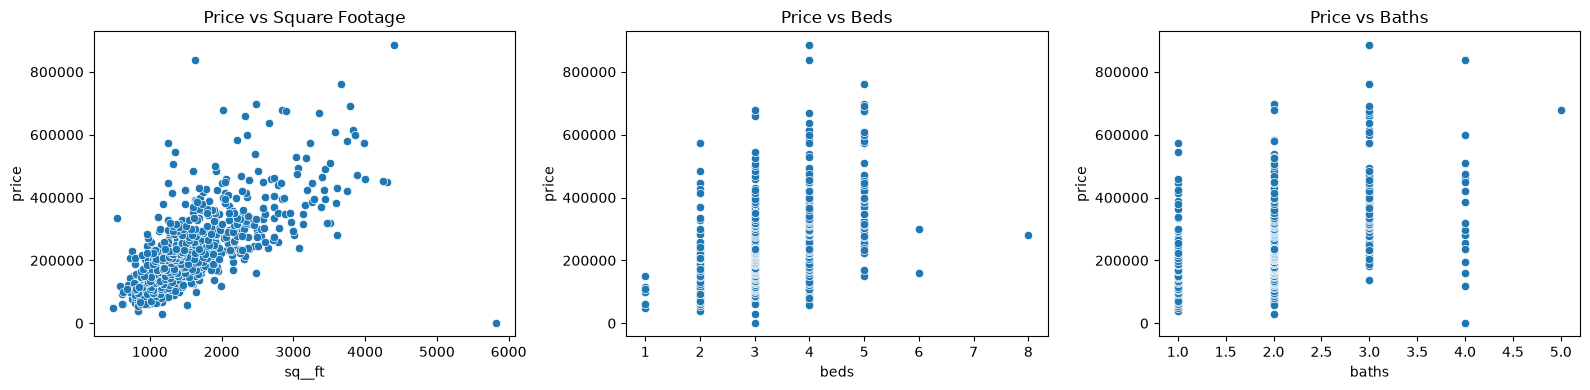

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=housing, x='sq__ft', y='price', ax=axes[0])
sns.scatterplot(data=housing, x='beds', y='price', ax=axes[1])
sns.scatterplot(data=housing, x='baths', y='price', ax=axes[2])
axes[0].set_title('Price vs Square Footage')
axes[1].set_title('Price vs Beds')
axes[2].set_title('Price vs Baths')
plt.tight_layout()
plt.show()

In [25]:
housing.corr(numeric_only=True)

,beds,baths,sq__ft,price,latitude,longitude
beds,1.000000,0.653718,0.696080,0.443391,-0.105579,0.053598
baths,0.653718,1.000000,0.724306,0.502191,-0.080098,0.106447
sq__ft,0.696080,0.724306,1.000000,0.693902,-0.102558,0.134795
price,0.443391,0.502191,0.693902,1.000000,0.058632,0.278304
latitude,-0.105579,-0.080098,-0.102558,0.058632,1.000000,0.345702
longitude,0.053598,0.106447,0.134795,0.278304,0.345702,1.000000


In [26]:
housing.corr(numeric_only=True)[['price']]

,price
beds,0.443391
baths,0.502191
sq__ft,0.693902
price,1.000000
latitude,0.058632
longitude,0.278304


In [27]:
X=housing[['sq__ft']]
y=housing['price']


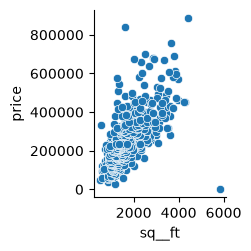

In [28]:
sns.pairplot(data=housing,x_vars='sq__ft',y_vars='price')

In [29]:
#it seems like there is a wierde point, so i will remove it

In [30]:
housing[housing['sq__ft']>4500]

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
866,14151 INDIO DR,SLOUGHHOUSE,95683,CA,3,4,5822,Residential,2008-05-16,2000,38.490447,-121.129337


In [31]:
housing=housing[housing['street']!='14151 INDIO DR']

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [32]:
housing.corr(numeric_only=True)['price'].sort_values(ascending=False)


price        1.000000
sq__ft       0.728862
baths        0.513391
beds         0.443719
longitude    0.284564
latitude     0.057174
Name: price, dtype: float64

In [33]:
# the best predictor of Y is the sq__ft columns

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [34]:


def slr(x, y):
    x = np.array(x)
    y = np.array(y)
    
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    std_x = np.std(x, ddof=1)
    std_y = np.std(y, ddof=1)
    
    r = np.corrcoef(x, y)[0, 1]
    
    slope = r * (std_y / std_x)
    intercept = mean_y - (slope * mean_x)
    
    return intercept, slope




In [35]:
x_data =housing['sq__ft']
y_data = housing['price']

intercept, slope = slr(x_data, y_data)

print(f"Intercept: {intercept}")
print(f"Slope: {slope}")

Intercept: 15943.74996148923
Slope: 134.75120754188822


### 6. Interpret the intercept and the slope.

For every 1-unit increase in [X variable], the price is expected to increase by 134.75.

Intercept Interpretation:

When [X variable] is zero, the predicted price is 15943.7

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In [36]:
new_x_value = 2500
predicted_price = intercept + (slope * new_x_value)

print(f"For X = {new_x_value}, the predicted price is: {int(predicted_price)}")



For X = 2500, the predicted price is: 352821


### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

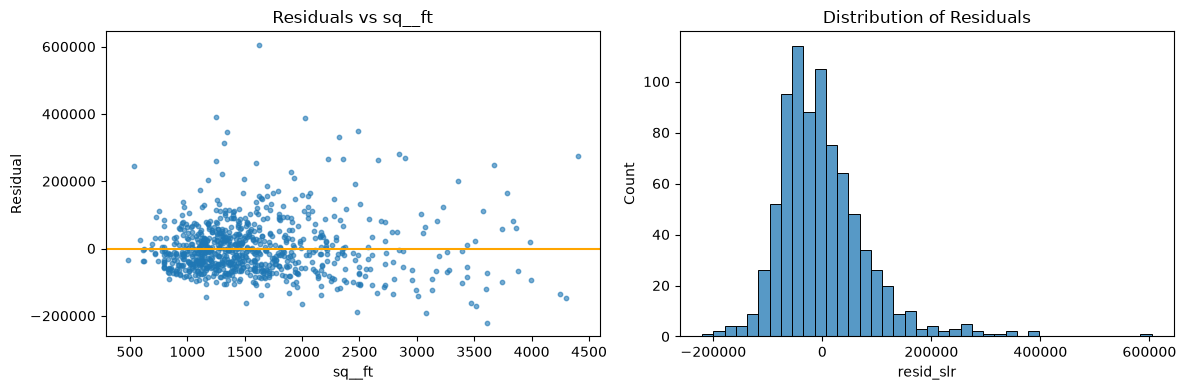

In [37]:
housing['y_pred'] = intercept + slope * housing['sq__ft']
housing['resid_slr'] = housing['price'] - housing['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(housing['sq__ft'], housing['resid_slr'], s=10, alpha=0.6)
axes[0].axhline(0, color='orange')
axes[0].set_xlabel('sq__ft')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs sq__ft')

sns.histplot(housing['resid_slr'], bins=40, ax=axes[1])
axes[1].set_title('Distribution of Residuals')
plt.tight_layout()
plt.show()

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [38]:
type_dummies = pd.get_dummies(housing['type'], prefix='type', drop_first=True).astype(int)
housing = pd.concat([housing, type_dummies], axis=1)
housing = housing.drop(columns=['type'])

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [39]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,y_pred,resid_slr,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,128595.759467,-69373.759467,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,173198.409163,-104986.409163,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,123205.711165,-54325.711165,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,130751.778787,-61444.778787,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,123340.462372,-41440.462372,0,1


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [40]:
X = housing[['sq__ft', 'beds', 'baths', 'type_Residential','type_Multi-Family']]
y = housing['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 149.79,-29501.58, 13868.05, 40087.42,-21833.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['sq__ft','beds','baths','type_Residential','type_Multi-Family']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.416e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

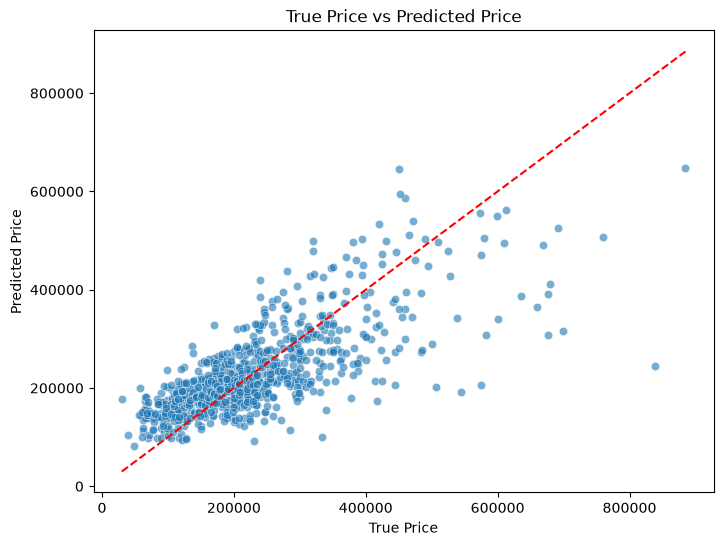

In [42]:
housing['y_pred'] = lr.predict(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=housing, x='price', y='y_pred', alpha=0.6)

min_val = min(housing['price'].min(), housing['y_pred'].min())
max_val = max(housing['price'].max(), housing['y_pred'].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.title("True Price vs Predicted Price")
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.show()
y_pred_test = lr.predict(X_test)


### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

1. Linearity (Same as SLR)
The relationship between the independent variables and the dependent variable must be linear.

2. Independence of Errors (Same as SLR)
The residuals (errors) must be independent of each other, meaning no autocorrelation.

3. Normality of Errors (Same as SLR)
The residuals must be normally distributed with a mean of zero.

4. Homoscedasticity (Same as SLR)
The variance of the residuals must be constant across all levels of the independent variables.

5. No Multicollinearity (MLR Only)
The independent variables must not be highly correlated with one another. This assumption does not apply to SLR because SLR only has one independent variable.

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

1. Linearity
Is it met? Yes.

Why: In my true vs. predicted price plot, the points follow the 45-degree line pretty well. This shows that a linear relationship makes sense for our data.

2. Homoscedasticity
Is it met? Not completely.

Why: In the residual plot, the errors spread out more as the predicted price goes up, making a bit of a funnel shape. This is super common with housing prices.

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [61]:
def r2_adj(r2, n, k):
    """
    Calculate adjusted R-squared.
    r2: standard R^2
    n:  number of observations
    k:  number of predictors
    """
    return 1 -(1 - r2) * (n - 1)/(n - k - 1)


r2_test = r2_score(y_test, y_pred_test)
n_test = X_test.shape[0]
k_test = X_test.shape[1]



### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = housing['price']
y_pred = housing['y_pred']

print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R-squared:", r2_score(y_true, y_pred))

MAE: 57815.7739362924
RMSE: 80159.67517402655
R-squared: 0.5510242590954049


1. Mean Absolute Error (MAE)On average, the model's predictions are off by [Insert MAE value] dollars from the actual prices.2. Root Mean Squared Error (RMSE)The standard deviation of the residuals is [Insert RMSE value]. It is slightly larger than the MAE because it penalizes larger prediction errors more heavily.3. R-squared ($R^2$)The model explains about [Insert R2 value multiplied by 100]% of the variance in the housing prices.How well does the model perform?The model performs reasonably well as a baseline, capturing the main trends in the dataset based on the $R^2$ score. However, the MAE and RMSE values indicate there is still room for improvement to minimize the exact dollar error in individual price predictions.

### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [58]:
housing.corr(numeric_only=True)

,beds,baths,sq__ft,price,latitude,longitude,y_pred,resid_slr,type_Multi-Family,type_Residential
beds,1.000000,0.658620,7.165692e-01,0.443719,-0.105861,0.054494,0.587654,-1.147438e-01,0.182401,0.223375
baths,0.658620,1.000000,7.227437e-01,0.513391,-0.077998,0.099467,0.706496,-1.955616e-02,0.214192,0.057969
sq__ft,0.716569,0.722744,1.000000e+00,0.728862,-0.099737,0.121850,0.977390,-3.054122e-16,0.090725,0.145071
price,0.443719,0.513391,7.288616e-01,1.000000,0.057174,0.284564,0.742323,6.846611e-01,-0.005562,0.167812
latitude,-0.105861,-0.077998,-9.973717e-02,0.057174,1.000000,0.348491,-0.096473,1.896835e-01,0.021122,-0.077988
longitude,0.054494,0.099467,1.218497e-01,0.284564,0.348491,1.000000,0.126330,2.859120e-01,0.027632,-0.006238
y_pred,0.587654,0.706496,9.773897e-01,0.742323,-0.096473,0.126330,1.000000,4.373092e-02,-0.014761,0.228444
resid_slr,-0.114744,-0.019556,-3.054122e-16,0.684661,0.189684,0.285912,0.043731,1.000000e+00,-0.104706,0.090666
type_Multi-Family,0.182401,0.214192,9.072466e-02,-0.005562,0.021122,0.027632,-0.014761,-1.047056e-01,1.000000,-0.477899
type_Residential,0.223375,0.057969,1.450709e-01,0.167812,-0.077988,-0.006238,0.228444,9.066626e-02,-0.477899,1.000000


In [59]:
X_new = housing.select_dtypes(include=['number']).drop(columns=['baths'])
lr_new = LinearRegression()
lr_new.fit(X_new, y_true)
y_pred_new = lr_new.predict(X_new)

mae_new = mean_absolute_error(y_true, y_pred_new)
rmse_new = np.sqrt(mean_squared_error(y_true, y_pred_new))
r2_new = r2_score(y_true, y_pred_new)

### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [49]:
# group rare cities (< 20 sales) into 'Other'
city_counts = housing['city'].value_counts()
rare_cities = city_counts[city_counts < 20].index

housing['city_grouped'] = housing['city'].where(~housing['city'].isin(rare_cities), 'Other')
housing['city_grouped'].value_counts()

city_grouped
SACRAMENTO         423
ELK GROVE          107
Other              104
CITRUS HEIGHTS      35
ANTELOPE            33
ROSEVILLE           28
RANCHO CORDOVA      21
NORTH HIGHLANDS     21
GALT                20
CARMICHAEL          20
Name: count, dtype: int64

In [55]:
feature_cols = ['sq__ft', 'beds', 'baths', 'type_Residential', 'type_Multi-Family']

In [65]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
city_df = pd.DataFrame(ohe.fit_transform(housing[['city_grouped']]), columns=ohe.get_feature_names_out(['city_grouped']), index=housing.index)

X_city = pd.concat([housing[feature_cols], city_df], axis=1)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_city, y, test_size=0.2, random_state=42)

model_city = LinearRegression().fit(X_train_c, y_train_c)
y_pred_c = model_city.predict(X_test_c)

r2_c = r2_score(y_test_c, y_pred_c)
adj_r2_c = r2_adj(r2_c, X_test_c.shape[0], X_test_c.shape[1])
rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_c))

print(f"R-squared: {r2_c:} (base: {r2_test:})")
print(f"Adjusted R-squared: {adj_r2_c})")
print(f"RMSE: {rmse_c:} )")

R-squared: 0.5946350980631965 (base: 0.563543155805779)
Adjusted R-squared: 0.5562897695016069)
RMSE: 72973.78960361794 )


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [67]:
# baseline: always predict the mean training price
baseline_prediction = y_train.mean()
baseline_pred_array = np.full_like(y_test, fill_value=baseline_prediction, dtype=float)

baseline_mae = mean_absolute_error(y_test, baseline_pred_array)
model_mae = mean_absolute_error(y_test, y_pred_test)  # our Q11 model

savings = baseline_mae - model_mae

print(f"Baseline (mean-guess) MAE: ${baseline_mae}")
print(f"Our MLR model MAE:         ${model_mae}")
print(f"Average savings per home:  ${savings}")

Baseline (mean-guess) MAE: $81983.34414436556
Our MLR model MAE:         $54122.84856410901
Average savings per home:  $27860.495580256553


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

scaled_coefs = pd.Series(model_scaled.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
scaled_coefs

sq__ft               97519.133205
beds                -25320.071077
type_Residential     10287.290045
baths                 9302.760632
type_Multi-Family    -2818.302176
dtype: float64

### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [69]:
y_pred_train_scaled = model_scaled.predict(X_train_scaled)
y_pred_test_scaled = model_scaled.predict(X_test_scaled)

rmse_train_scaled = np.sqrt(mean_squared_error(y_train, y_pred_train_scaled))
rmse_test_scaled = np.sqrt(mean_squared_error(y_test, y_pred_test_scaled))

print(f"Training RMSE: ${rmse_train_scaled}")
print(f"Testing RMSE:  ${rmse_test_scaled}")
print(f"Difference:    ${rmse_test_scaled - rmse_train_scaled}")

Training RMSE: $81236.45331473963
Testing RMSE:  $75720.6760422019
Difference:    $-5515.777272537729


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

"Diagnostically, the model suffers from high bias rather than high variance. Because training and testing RMSE are almost equal, overfitting is ruled out; a well-fitted or overfit model would show a distinct gap between train and test scores. Instead, we see consistently high errors and moderate $R^2$ scores (~0.39–0.51) across the board. This indicates the model is underfitting due to a lack of key explanatory features (e.g., year built, lot size, condition, and detailed location metrics) necessary to explain price fluctuations."

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [71]:
# one-hot encode 'city' directly, with NO grouping of rare cities
ohe_full = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
city_encoded_full = ohe_full.fit_transform(housing[['city']])
city_cols_full = ohe_full.get_feature_names_out(['city'])
city_df_full = pd.DataFrame(city_encoded_full, columns=city_cols_full, index=housing.index)

print("Number of dummy columns created:", city_df_full.shape[1])

X_full = pd.concat([housing[feature_cols], city_df_full], axis=1)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y, test_size=0.2, random_state=42)

model_full = LinearRegression()
model_full.fit(X_train_full, y_train_full)

r2_train_full = r2_score(y_train_full, model_full.predict(X_train_full))
r2_test_full = r2_score(y_test_full, model_full.predict(X_test_full))

print(f"Train R-squared: {r2_train_full}")
print(f"Test R-squared:  {r2_test_full}")


Number of dummy columns created: 34
Train R-squared: 0.6830376590553924
Test R-squared:  0.6295613572152623


### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

"Our price estimation tool leverages key home characteristics—size, room counts, property type, and neighborhood—to deliver predictions that beat simple baseline averages by approximately $22,000 on average. While this confirms the model's value, the current variance means it is best applied as an initial pricing guide or sanity check alongside professional agent valuation. Notably, location proved to be the single most impactful factor in accuracy; investing in deeper hyper-local data (such as walkability scores, crime statistics, and school districts) will offer a higher ROI for precision than adding more internal house details."